Carregando dados para plotagem comparativa...

Gráfico comparativo exportado com sucesso como 'comparativo_tradeoff_modelos_tcc.png'.


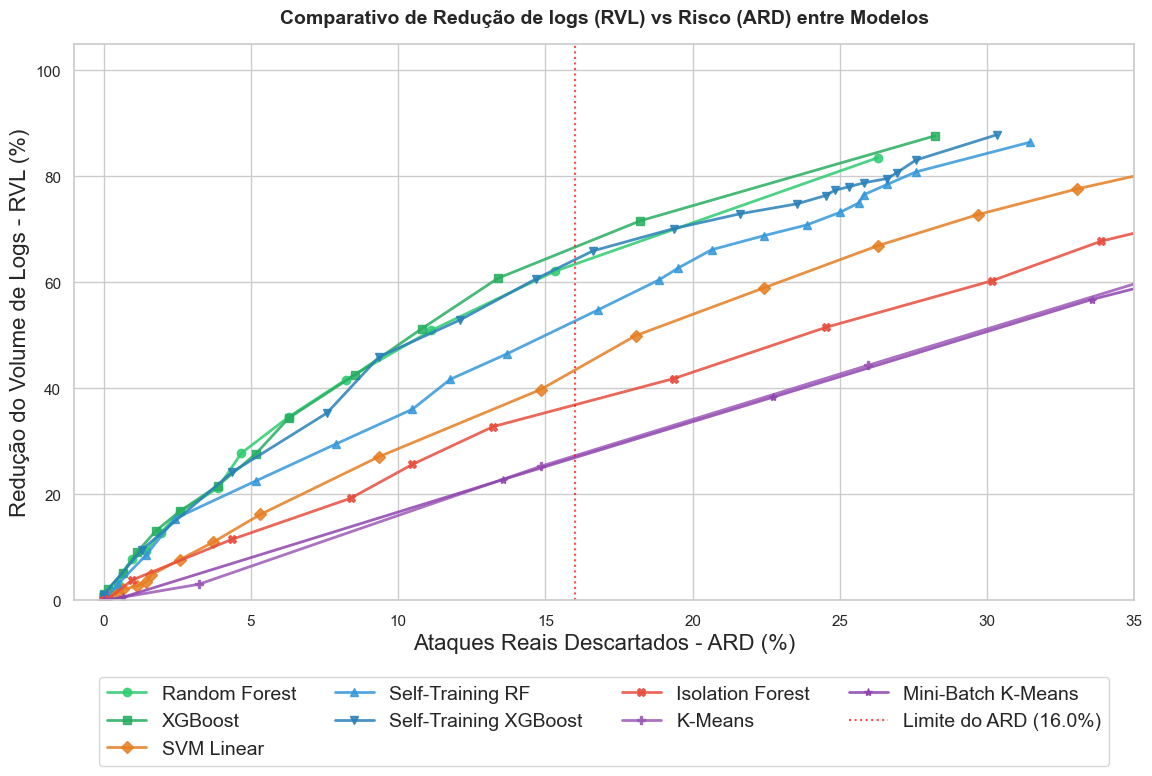

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

# ==========================================
# 1. CONFIGURAÇÃO DOS MODELOS E ARQUIVOS
# ==========================================
print("="*50)
print("Carregando dados para plotagem comparativa...")
print("="*50)

# Dicionário contendo o nome do arquivo, a label que aparecerá na legenda e as configurações visuais
modelos = {
    'tradeoff_rf.csv':    {'label': 'Random Forest',          'color': '#2ecc71', 'marker': 'o'}, # Verde
    'tradeoff_xgb.csv':   {'label': 'XGBoost',                'color': '#27ae60', 'marker': 's'}, # Verde Escuro
    'tradeoff_svm.csv':   {'label': 'SVM Linear',             'color': '#e67e22', 'marker': 'D'}, # Laranja
    'tradeoff_strf.csv':  {'label': 'Self-Training RF',       'color': '#3498db', 'marker': '^'}, # Azul
    'tradeoff_stxgb.csv': {'label': 'Self-Training XGBoost',  'color': '#2980b9', 'marker': 'v'}, # Azul Escuro
    'tradeoff_if.csv':    {'label': 'Isolation Forest',       'color': '#e74c3c', 'marker': 'X'}, # Vermelho
    'tradeoff_km.csv':    {'label': 'K-Means',                'color': '#9b59b6', 'marker': 'P'}, # Roxo
    'tradeoff_mbkm.csv':  {'label': 'Mini-Batch K-Means',     'color': '#8e44ad', 'marker': '*'}  # Roxo Escuro
}

# ==========================================
# 2. PLOTAGEM DA CURVA DE PARETO (TRADE-OFF)
# ==========================================
plt.figure(figsize=(12, 8))

ard_limit = 16.0 

for arquivo, config in modelos.items():
    if os.path.exists(arquivo):
        df = pd.read_csv(arquivo)
        
        # EIXOS INVERTIDOS: X agora é ARD (Perda) e Y é RVL (Ganho)
        plt.plot(df['ARD'], df['RVL'], 
                 label=config['label'], 
                 color=config['color'], 
                 marker=config['marker'], 
                 linewidth=2, 
                 markersize=6, 
                 alpha=0.85)
    else:
        print(f"[AVISO] Arquivo {arquivo} não encontrado na pasta atual.")

# Como o ARD agora está no eixo X, a linha de limite fica vertical
plt.axvline(x=ard_limit, color='red', linestyle=':', alpha=0.7, label=f'Limite do ARD ({ard_limit}%)')

plt.title('Comparativo de Redução de logs (RVL) vs Risco (ARD) entre Modelos', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ataques Reais Descartados - ARD (%)', fontsize=16) # Agora no Eixo X
plt.ylabel('Redução do Volume de Logs - RVL (%)', fontsize=16) # Agora no Eixo Y

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=14, frameon=True)

plt.xlim(-1, 35) 
plt.ylim(0, 105)

plt.tight_layout()

# ==========================================
# 3. EXPORTANDO A IMAGEM EM ALTA RESOLUÇÃO
# ==========================================
nome_imagem = 'comparativo_tradeoff_modelos_tcc.png'
plt.savefig(nome_imagem, dpi=300, format='png', bbox_inches='tight')

print(f"\nGráfico comparativo exportado com sucesso como '{nome_imagem}'.")
plt.show()